In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

EPS = 1e-7


In [3]:
def load(input):
    df = pd.read_csv(f'Outputs/Monotonicity outputs/{input}.csv', header = None)
    df.columns = [f'Y{i+1}' for i in range(len(df.columns))]
    input_df = pd.read_csv(f'Inputs/Monotonicity inputs/{input}.txt', header = None)
    input_df.columns = [f'X{i+1}' for i in range(len(input_df.columns))]

    return df, input_df

def is_monotone(df, input_df, cols_all, seed_diff = True):
    monotone_type = dict()
    down_sample = dict()
    up_sample = dict()
    neither_sample = dict()
    
    for i in range(1, df['Y7'].max()+1):
        sample_df = df[df['Y7'] == i].drop('Y7', axis = 1).reset_index(drop=True)
        for j in range(i+1, df['Y7'].max()+1):
            flag = np.all([input_df[col][i-1] == input_df[col][j-1] for col in cols_all])
            if flag:
                continue
            
            if seed_diff and input_df['X9'][i-1] != input_df['X9'][j-1]:
                continue
                
            
            sample_df2 = df[df['Y7'] == j].drop('Y7', axis = 1).reset_index(drop=True)
            for col in sample_df.columns:
                up = np.all(sample_df[col] - sample_df2[col] >= 0)
                down = np.all(sample_df[col] - sample_df2[col] < 0)
                
                if col not in monotone_type:
                    monotone_type[col] = set()
                
                if (not up) and (not down):
                    monotone_type[col].add('neither')
                    if col not in neither_sample:
                        neither_sample[col] = sample_df[col] - sample_df2[col]
                        
                elif up:
                    monotone_type[col].add('up')
                    if col not in up_sample:
                        up_sample[col] = sample_df[col] - sample_df2[col] # Add an example to check if the code is correct.
                elif down:
                    monotone_type[col].add('down')
                    if col not in down_sample:
                        down_sample[col] = sample_df[col] - sample_df2[col]
    
    print(monotone_type)                
    return monotone_type, (up_sample, down_sample, neither_sample)


def plot_cols(df, plot_type='l', show_marks = True):
    _, axs = plt.subplots(2, 3, figsize=(15, 10))
    
    for i, ax in enumerate(axs.flat):
        if plot_type == 'l':
            sns.lineplot(x=df.index, y=df[f'Y{i+1}'], ax=ax, label=f'Y{i+1}')
        elif plot_type == 'o':
            ax.scatter(df.index, df[f'Y{i+1}'], color='blue', label=f'Y{i+1}', s=10)

        # Get red and green points
        x_steps_red = df.index[::10]  
        y_steps_red = df[f'Y{i+1}'].iloc[::10]

        x_steps_green = df.index[9::10]  
        y_steps_green = df[f'Y{i+1}'].iloc[9::10]

        # Yellow points every 5th step in each group
        x_steps_yellow = []
        y_steps_yellow = []

        for group_start in range(0, len(df), 10):
            if group_start + 10 < len(df):
                last_point = df[f'Y{i+1}'].iloc[group_start + 9]  # 9th index of the group
                first_next_group = df[f'Y{i+1}'].iloc[group_start + 10]  # First index of next group

                if last_point != first_next_group:
                    x_steps_yellow.append(group_start + 5)  # 5th index of the group
                    y_steps_yellow.append(df[f'Y{i+1}'].iloc[group_start + 5])

        # Plot green, red, and yellow points
        if show_marks:
            ax.scatter(x_steps_green, y_steps_green, color='green', label='Last point at ith sample group', zorder=3)
            ax.scatter(x_steps_red, y_steps_red, color='red', label='First point of ith sample group', zorder=4)
            ax.scatter(x_steps_yellow, y_steps_yellow, color='yellow', label='5th point (if group changes)', zorder=5)

        ax.set_title(f'Y{i+1}')
    
    plt.tight_layout()
    plt.legend(loc='best')
    plt.show()


    

# X1

Sample strategy: let X1 = {0.0, 0.1, 0.2, 0.3, ..., 1.0} be the values of Xa1 (11 in total)

                 let W = {1, 2, 3, ..., 100} be the seeds. (100 in total)

                 the samples tested are all a from X1xW. (i.e. a = (x, w), x from X1, w from W)

                 Total samples: 1100.

In [24]:
df = pd.read_csv('Outputs\Monotonicity outputs\X1.csv', header = None)
df.columns = [f'Y{i+1}' for i in range(len(df.columns))]
input_df = pd.read_csv('Inputs\Monotonicity inputs\X1.txt', header = None)
input_df.columns = [f'X{i+1}' for i in range(len(input_df.columns))]


<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:3: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:3: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Alex\AppData\Local\Temp\ipykernel_21972\4235068069.py:1: SyntaxWarning: invalid escape sequence '\M'
  df = pd.read_csv('Outputs\Monotonicity outputs\X1.csv', header = None)
C:\Users\Alex\AppData\Local\Temp\ipykernel_21972\4235068069.py:3: SyntaxWarning: invalid escape sequence '\M'
  input_df = pd.read_csv('Inputs\Monotonicity inputs\X1.txt', header = None)


In [25]:
df

,Y1,Y2,Y3,Y4,Y5,Y6,Y7
0,0.00,0.00,0.00,0.000000,0.000000,0.000000,1
1,0.00,0.00,0.00,0.000000,0.000000,0.000000,1
2,0.00,0.00,0.00,0.000000,0.000000,0.000000,1
3,0.00,0.00,0.00,0.000000,0.000000,0.000000,1
4,0.00,0.00,0.00,0.000000,0.000000,0.000000,1
...,...,...,...,...,...,...,...
65995,3.35,3.35,3.35,6136.072152,1766.580012,2418.190131,1100
65996,3.35,3.35,3.35,6136.072152,1766.580012,2418.190131,1100
65997,3.35,3.35,3.35,6136.072152,1766.580012,2418.190131,1100
65998,3.35,3.35,3.35,6136.072152,1766.580012,2418.190131,1100


In [26]:
df = df.drop('Y7', axis = 1).drop_duplicates(keep='first').reset_index(drop=True)
print(len(df))
df

11


,Y1,Y2,Y3,Y4,Y5,Y6
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.006406,0.000000,0.013614,61.360722,17.665800,24.181901
2,1.880383,0.000000,2.851364,245.442886,70.663200,96.727605
3,3.350000,0.036995,3.350000,552.246494,158.992201,217.637112
4,3.350000,0.426589,3.350000,981.771544,282.652802,386.910421
5,3.350000,1.735914,3.350000,1534.018038,441.645003,604.547533
6,3.350000,3.350000,3.350000,2208.985975,635.968804,870.548447
7,3.350000,3.350000,3.350000,3006.675354,865.624206,1184.913164
8,3.350000,3.350000,3.350000,3927.086177,1130.611208,1547.641684
9,3.350000,3.350000,3.350000,4970.218443,1430.929810,1958.734006


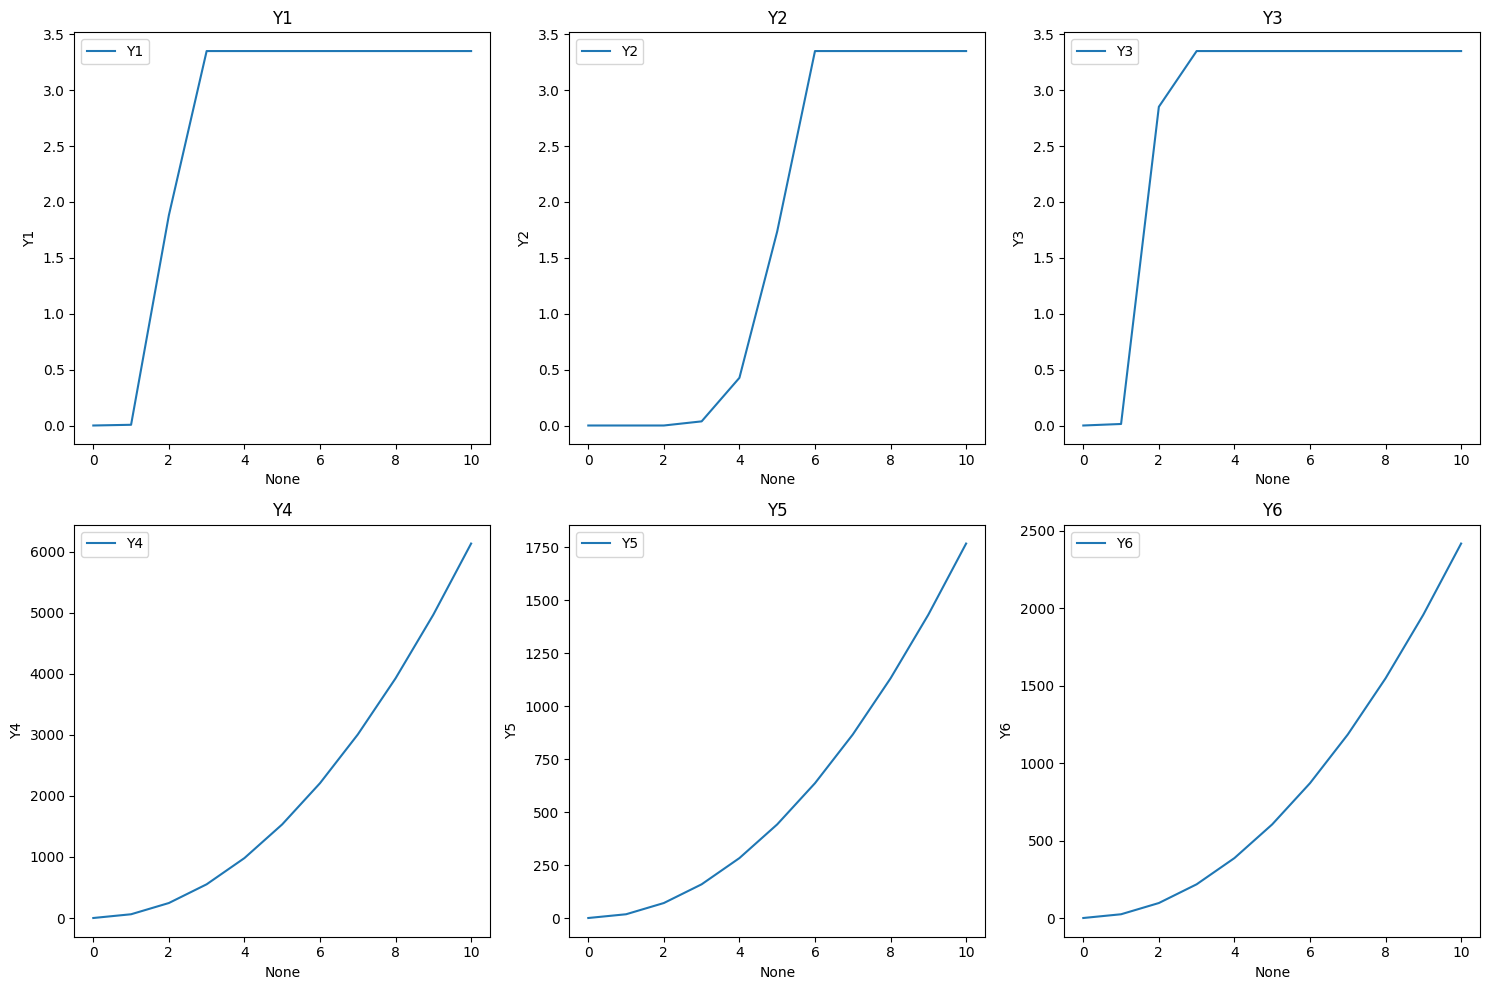

In [27]:
plot_cols(df, plot_type = 'l', show_marks=False)

Xa1 is monotone, constant, seed-invariant.

# X2

In [45]:
df, input_df = load('X2')
df

,Y1,Y2,Y3,Y4,Y5,Y6,Y7
0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,1
1,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,1
2,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,1
3,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,1
4,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,1
...,...,...,...,...,...,...,...
65995,0.000111,0.0,0.000322,0.000000,0.000000,0.000000,1100
65996,0.000099,0.0,0.000290,0.000000,0.000000,0.000000,1100
65997,0.000090,0.0,0.000261,0.000000,0.000000,0.000000,1100
65998,0.000081,0.0,0.000235,21.210944,6.106647,8.359109,1100


In [48]:
df.iloc[6060:6120]

,Y1,Y2,Y3,Y4,Y5,Y6,Y7
6060,0.0,0.0,0.0,0.000000,0.000000e+00,0.000000e+00,102
6061,0.0,0.0,0.0,0.169454,4.878595e-02,6.678084e-02,102
6062,0.0,0.0,0.0,0.000135,3.885696e-05,5.318951e-05,102
6063,0.0,0.0,0.0,0.000000,0.000000e+00,0.000000e+00,102
6064,0.0,0.0,0.0,0.000000,0.000000e+00,0.000000e+00,102
6065,0.0,0.0,0.0,0.082812,2.384172e-02,3.263583e-02,102
6066,0.0,0.0,0.0,0.000000,0.000000e+00,0.000000e+00,102
6067,0.0,0.0,0.0,0.040460,1.164857e-02,1.594519e-02,102
6068,0.0,0.0,0.0,0.027994,8.059431e-03,1.103218e-02,102
6069,0.0,0.0,0.0,0.000000,0.000000e+00,0.000000e+00,102


Sample: 625, 0.6000000000000001


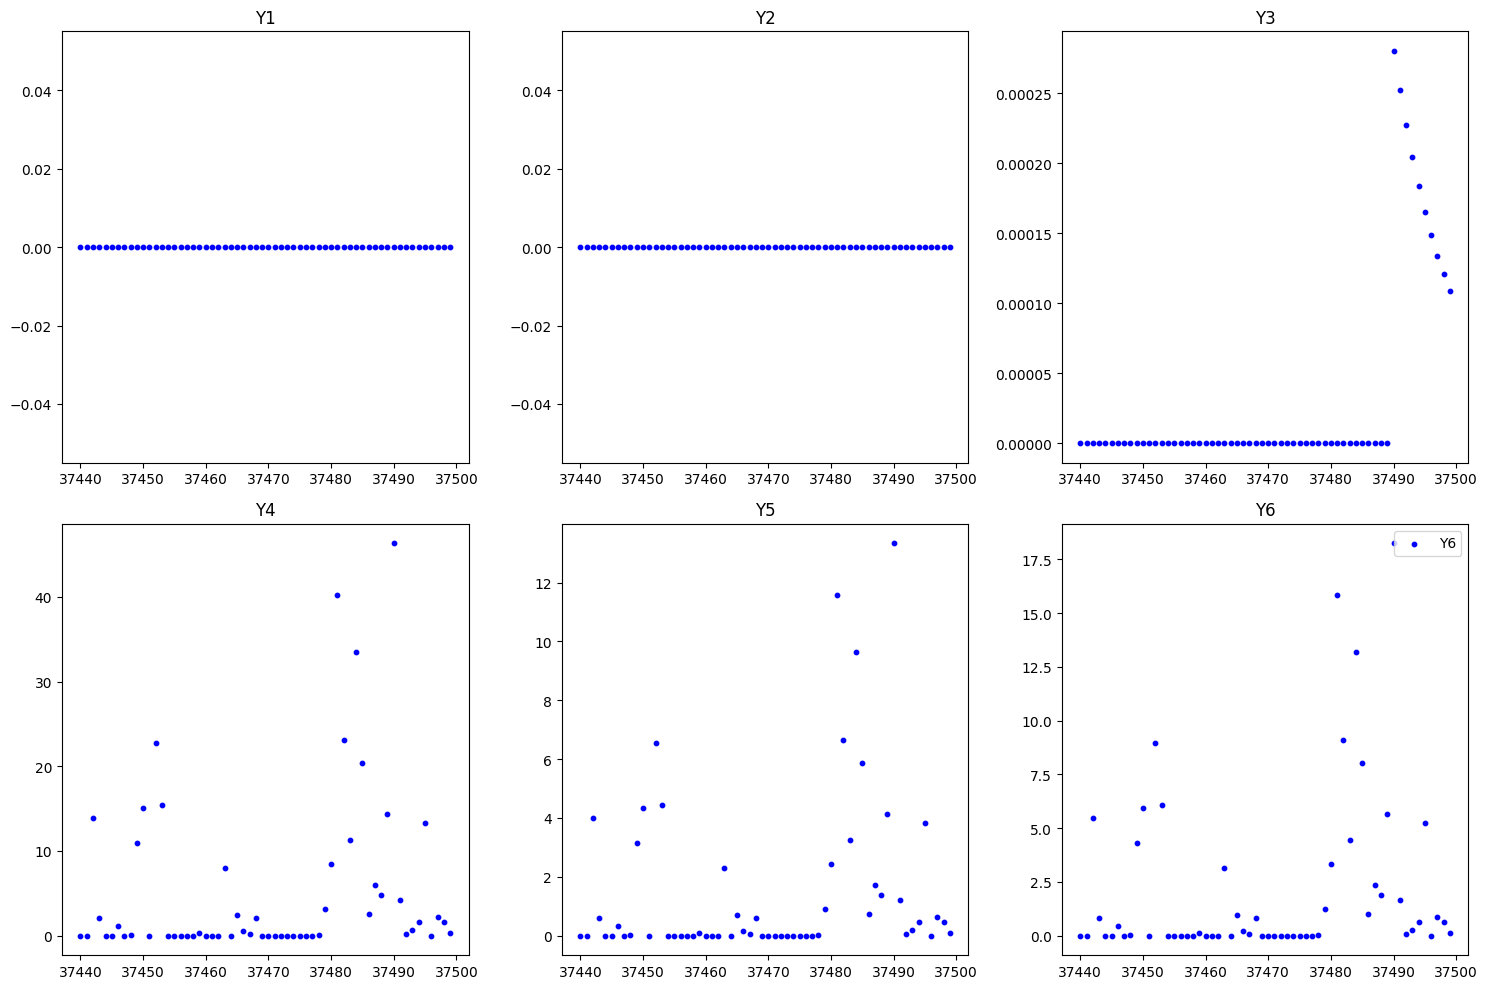

In [35]:
s = np.random.randint(0, 1100)
print(f'Sample: {s+1}, {input_df.iloc[s].iloc[1]}')
plot_cols(df.iloc[s*60:(s+1)*60], plot_type = 'o', show_marks = False)

# X1-2

For all the following code below a new sample strategy is applied:

Let X1 = {0.1, ... 1.0}

Xi = {0.1, ... 1.0}

W = {1, 2, ... 20}

a sample s = (x1, xi, w) from X1xXixW

Total samples: 2000 (10 x 10 x 20)

In [49]:
df, input_df = load('X1_X2')
df

,Y1,Y2,Y3,Y4,Y5,Y6,Y7
0,0.006406,0.00,0.013614,61.360722,17.665800,24.181901,1
1,0.006406,0.00,0.013614,61.360722,17.665800,24.181901,1
2,0.006406,0.00,0.013614,61.360722,17.665800,24.181901,1
3,0.006406,0.00,0.013614,61.360722,17.665800,24.181901,1
4,0.006406,0.00,0.013614,61.360722,17.665800,24.181901,1
...,...,...,...,...,...,...,...
131995,3.350000,3.35,3.350000,6125.256243,1763.466103,2413.927644,2200
131996,3.350000,3.35,3.350000,8089.008683,2328.831980,3187.830990,2200
131997,3.350000,3.35,3.350000,6667.893472,1919.691790,2627.777801,2200
131998,3.350000,3.35,3.350000,7295.191031,2100.291252,2874.992098,2200


Sample: 28, X1 = 0.1, X2 = 0.1, seed = 7.0


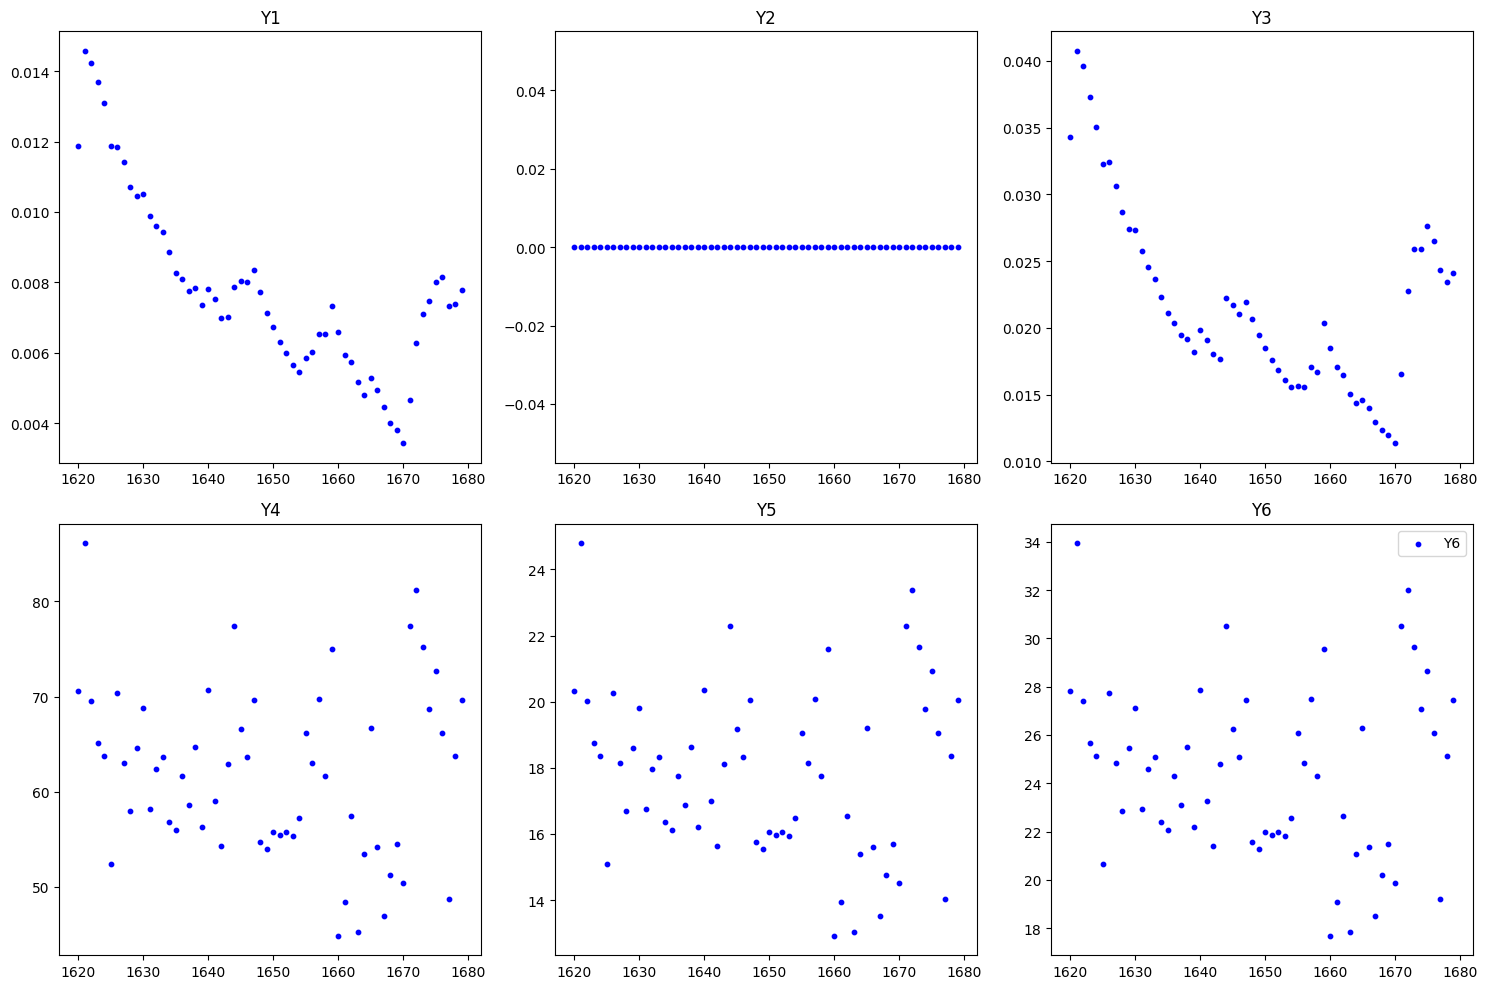

In [39]:
s = np.random.randint(0, 2200)
print(f'Sample: {s+1}, X1 = {round(input_df["X1"].loc[s-1], 8)}, X2 = {round(input_df["X2"].loc[s-1], 8)}, seed = {input_df["X9"].loc[s-1]}')
plot_cols(df.iloc[s*60:(s+1)*60], plot_type = 'o', show_marks = False)

# X3


In [40]:
df, input_df = load('X1_X3')
df

,Y1,Y2,Y3,Y4,Y5,Y6,Y7
0,0.004125,0.00,0.006185,64.743945,8.997096,21.027776,1
1,0.004125,0.00,0.006185,64.743945,8.997096,21.027776,1
2,0.004125,0.00,0.006185,64.743945,8.997096,21.027776,1
3,0.004125,0.00,0.006185,64.743945,8.997096,21.027776,1
4,0.004125,0.00,0.006185,64.743945,8.997096,21.027776,1
...,...,...,...,...,...,...,...
119995,3.350000,3.35,3.350000,6170.368388,1653.261627,2340.216826,2000
119996,3.350000,3.35,3.350000,6170.368388,1653.261627,2340.216826,2000
119997,3.350000,3.35,3.350000,6170.368388,1653.261627,2340.216826,2000
119998,3.350000,3.35,3.350000,6170.368388,1653.261627,2340.216826,2000


In [41]:
df = df.drop('Y7', axis = 1).drop_duplicates(keep='first').reset_index(drop=True)
df

,Y1,Y2,Y3,Y4,Y5,Y6
0,0.004125,0.00,0.006185,64.743945,8.997096,21.027776
1,0.004362,0.00,0.006614,64.410374,9.559840,20.959990
2,0.004597,0.00,0.007192,64.075722,10.195471,20.970163
3,0.004830,0.00,0.007891,63.740000,10.903045,21.041180
4,0.005062,0.00,0.008681,63.403215,11.681110,21.154640
...,...,...,...,...,...,...
95,3.350000,3.35,3.350000,6306.537722,1252.760935,2129.186898
96,3.350000,3.35,3.350000,6272.649600,1343.982001,2143.490554
97,3.350000,3.35,3.350000,6238.658048,1441.430424,2179.442740
98,3.350000,3.35,3.350000,6204.563999,1544.688215,2260.262128


Let G_x = {(x, y) | y from Xi} represent a group of elements with the same x1 value.

len(G_x) = 10.

The groups are sorted based on y. i.e G_x = [(x, y1), (x, y2), ..., (x, yn)], yi <= yj, i < j

Let red point be the first point of each group i.e (x,y1)

Let yellow point be the middle point of each gropu i.e (x,y5)

Let green point be the last point i.e (x, y10)


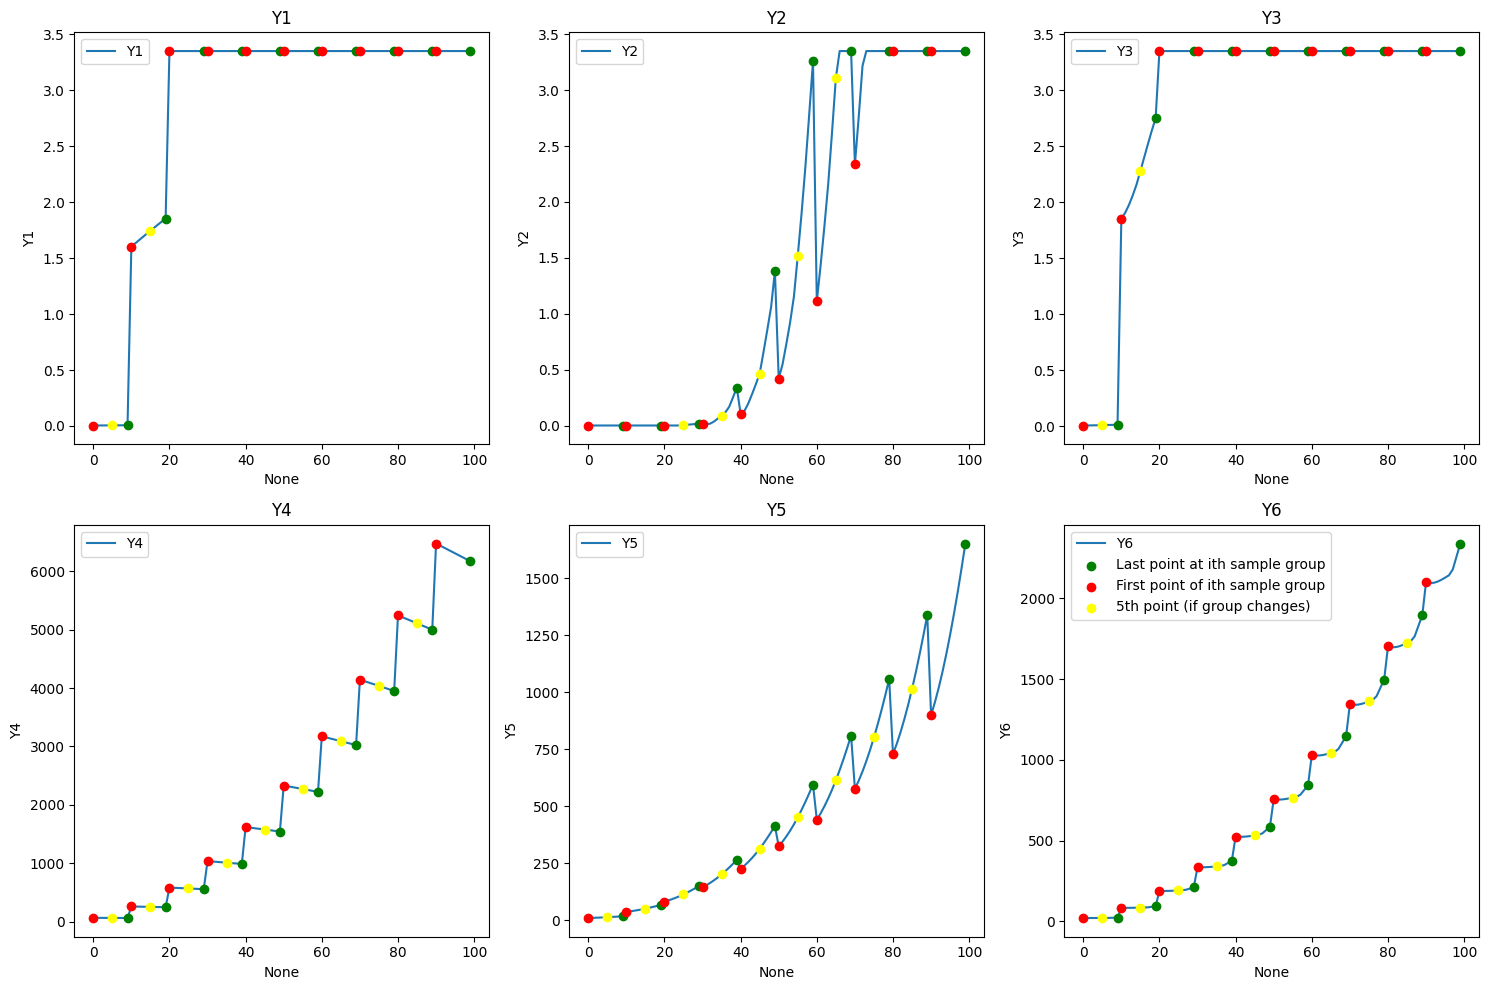

In [42]:
plot_cols(df)

# X4

In [67]:
df, input_df = load('X1_X4')
df

,Y1,Y2,Y3,Y4,Y5,Y6,Y7
0,0.006406,0.00,0.013237,61.360722,30.229269,23.961253,1
1,0.006406,0.00,0.013237,61.360722,30.229269,23.961253,1
2,0.006406,0.00,0.013237,61.360722,30.229269,23.961253,1
3,0.006406,0.00,0.013237,61.360722,30.229269,23.961253,1
4,0.006406,0.00,0.013237,61.360722,30.229269,23.961253,1
...,...,...,...,...,...,...,...
119995,3.350000,3.35,3.350000,6136.072152,1987.785094,2409.851598,2000
119996,3.350000,3.35,3.350000,6136.072152,1987.785094,2409.851598,2000
119997,3.350000,3.35,3.350000,6136.072152,1987.785094,2409.851598,2000
119998,3.350000,3.35,3.350000,6136.072152,1987.785094,2409.851598,2000


In [41]:
df = df.drop('Y7', axis = 1).drop_duplicates(keep='first').reset_index(drop=True)
df

,Y1,Y2,Y3,Y4,Y5,Y6
0,0.006406,0.00,0.013237,61.360722,30.229269,23.961253
1,0.006406,0.00,0.013214,61.360722,29.392972,23.947654
2,0.006406,0.00,0.013199,61.360722,28.511950,23.938706
3,0.006406,0.00,0.013193,61.360722,27.578796,23.935206
4,0.006406,0.00,0.013198,61.360722,26.583728,23.938081
...,...,...,...,...,...,...
95,3.350000,3.35,3.350000,6136.072152,2551.337749,2394.842456
96,3.350000,3.35,3.350000,6136.072152,2434.863308,2396.756423
97,3.350000,3.35,3.350000,6136.072152,2306.046553,2399.718284
98,3.350000,3.35,3.350000,6136.072152,2160.074626,2403.959804


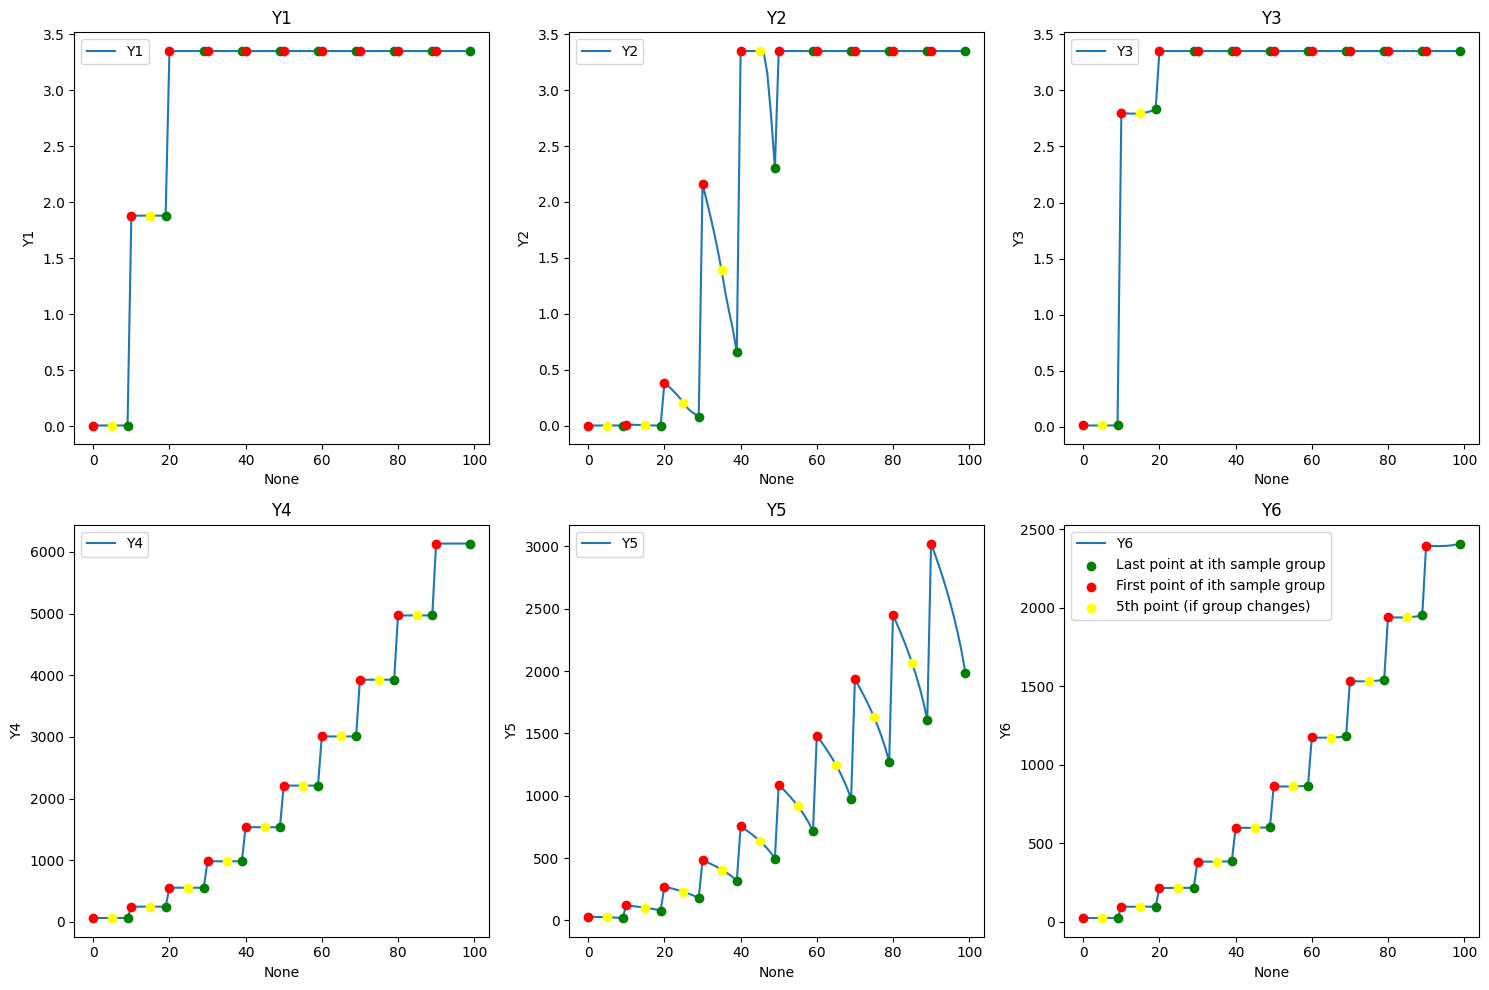

In [42]:
plot_cols(df)

# X5

In [68]:
df, input_df = load('X1_X5')
df

,Y1,Y2,Y3,Y4,Y5,Y6,Y7
0,0.006406,0.00,0.012141,61.360722,15.361358,23.324338,1
1,0.006406,0.00,0.012141,61.360722,15.361358,23.324338,1
2,0.006406,0.00,0.012141,61.360722,15.361358,23.324338,1
3,0.006406,0.00,0.012141,61.360722,15.361358,23.324338,1
4,0.006406,0.00,0.012141,61.360722,15.361358,23.324338,1
...,...,...,...,...,...,...,...
119995,3.350000,3.35,3.350000,6136.072152,1741.068974,2408.498247,2000
119996,3.350000,3.35,3.350000,6136.072152,1741.068974,2408.498247,2000
119997,3.350000,3.35,3.350000,6136.072152,1741.068974,2408.498247,2000
119998,3.350000,3.35,3.350000,6136.072152,1741.068974,2408.498247,2000


In [45]:
df = df.drop('Y7', axis = 1).drop_duplicates(keep='first').reset_index(drop=True)
df

,Y1,Y2,Y3,Y4,Y5,Y6
0,0.006406,0.00,0.012141,61.360722,15.361358,23.324338
1,0.006406,0.00,0.012270,61.360722,15.568896,23.398879
2,0.006406,0.00,0.012403,61.360722,15.781153,23.475855
3,0.006406,0.00,0.012540,61.360722,15.998262,23.555308
4,0.006406,0.00,0.012682,61.360722,16.220357,23.637270
...,...,...,...,...,...,...
95,3.350000,3.35,3.350000,6136.072152,1644.757974,2372.176489
96,3.350000,3.35,3.350000,6136.072152,1668.007323,2380.880029
97,3.350000,3.35,3.350000,6136.072152,1691.798650,2389.836959
98,3.350000,3.35,3.350000,6136.072152,1716.147273,2399.044663


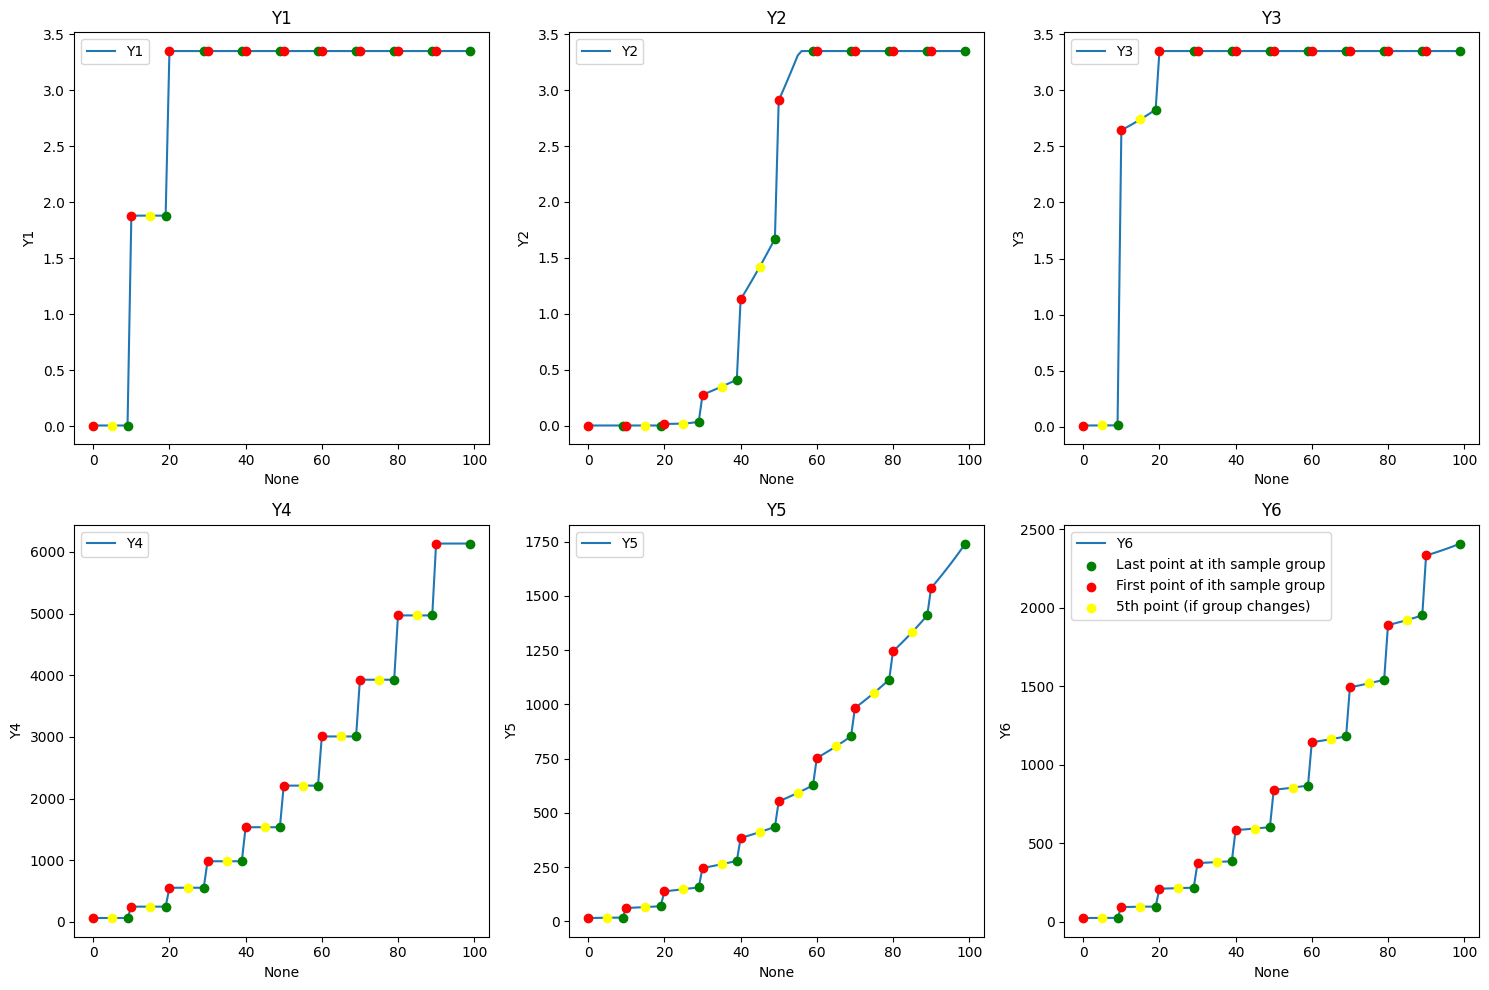

In [46]:
plot_cols(df)

# X6

In [43]:
df, input_df = load('X1_X6')
df

,Y1,Y2,Y3,Y4,Y5,Y6,Y7
0,0.00,0.00,0.009297,78.950485,25.294474,21.711779,1
1,0.00,0.00,0.009297,78.950485,25.294474,21.711779,1
2,0.00,0.00,0.009297,78.950485,25.294474,21.711779,1
3,0.00,0.00,0.009297,78.950485,25.294474,21.711779,1
4,0.00,0.00,0.009297,78.950485,25.294474,21.711779,1
...,...,...,...,...,...,...,...
119995,3.35,3.35,3.350000,5248.759200,927.729694,2414.976409,2000
119996,3.35,3.35,3.350000,5248.759200,927.729694,2414.976409,2000
119997,3.35,3.35,3.350000,5248.759200,927.729694,2414.976409,2000
119998,3.35,3.35,3.350000,5248.759200,927.729694,2414.976409,2000


In [44]:
df.iloc[:60]

,Y1,Y2,Y3,Y4,Y5,Y6,Y7
0,0.0,0.0,0.009297,78.950485,25.294474,21.711779,1
1,0.0,0.0,0.009297,78.950485,25.294474,21.711779,1
2,0.0,0.0,0.009297,78.950485,25.294474,21.711779,1
3,0.0,0.0,0.009297,78.950485,25.294474,21.711779,1
4,0.0,0.0,0.009297,78.950485,25.294474,21.711779,1
5,0.0,0.0,0.009297,78.950485,25.294474,21.711779,1
6,0.0,0.0,0.009297,78.950485,25.294474,21.711779,1
7,0.0,0.0,0.009297,78.950485,25.294474,21.711779,1
8,0.0,0.0,0.009297,78.950485,25.294474,21.711779,1
9,0.0,0.0,0.009297,78.950485,25.294474,21.711779,1


In [48]:
df = df.drop('Y7', axis = 1).drop_duplicates(keep='first').reset_index(drop=True)
df

,Y1,Y2,Y3,Y4,Y5,Y6
0,0.000000,0.000000,0.009297,78.950485,25.294474,21.711779
1,0.000000,0.000000,0.009262,71.688598,17.661636,21.692168
2,0.004908,0.000000,0.009608,63.627856,10.893120,21.884802
3,0.010049,0.000000,0.009497,54.906180,3.331669,21.823130
4,0.013844,0.000000,0.007931,45.672802,1.239732,20.957606
...,...,...,...,...,...,...
95,3.350000,0.368009,3.350000,3608.570583,268.104556,1977.482035
96,3.350000,1.361988,3.350000,2630.893048,405.770815,1988.443583
97,3.350000,2.336825,3.350000,3349.024103,499.893209,2151.837034
98,3.350000,1.191613,3.350000,4314.414217,389.928945,2339.367296


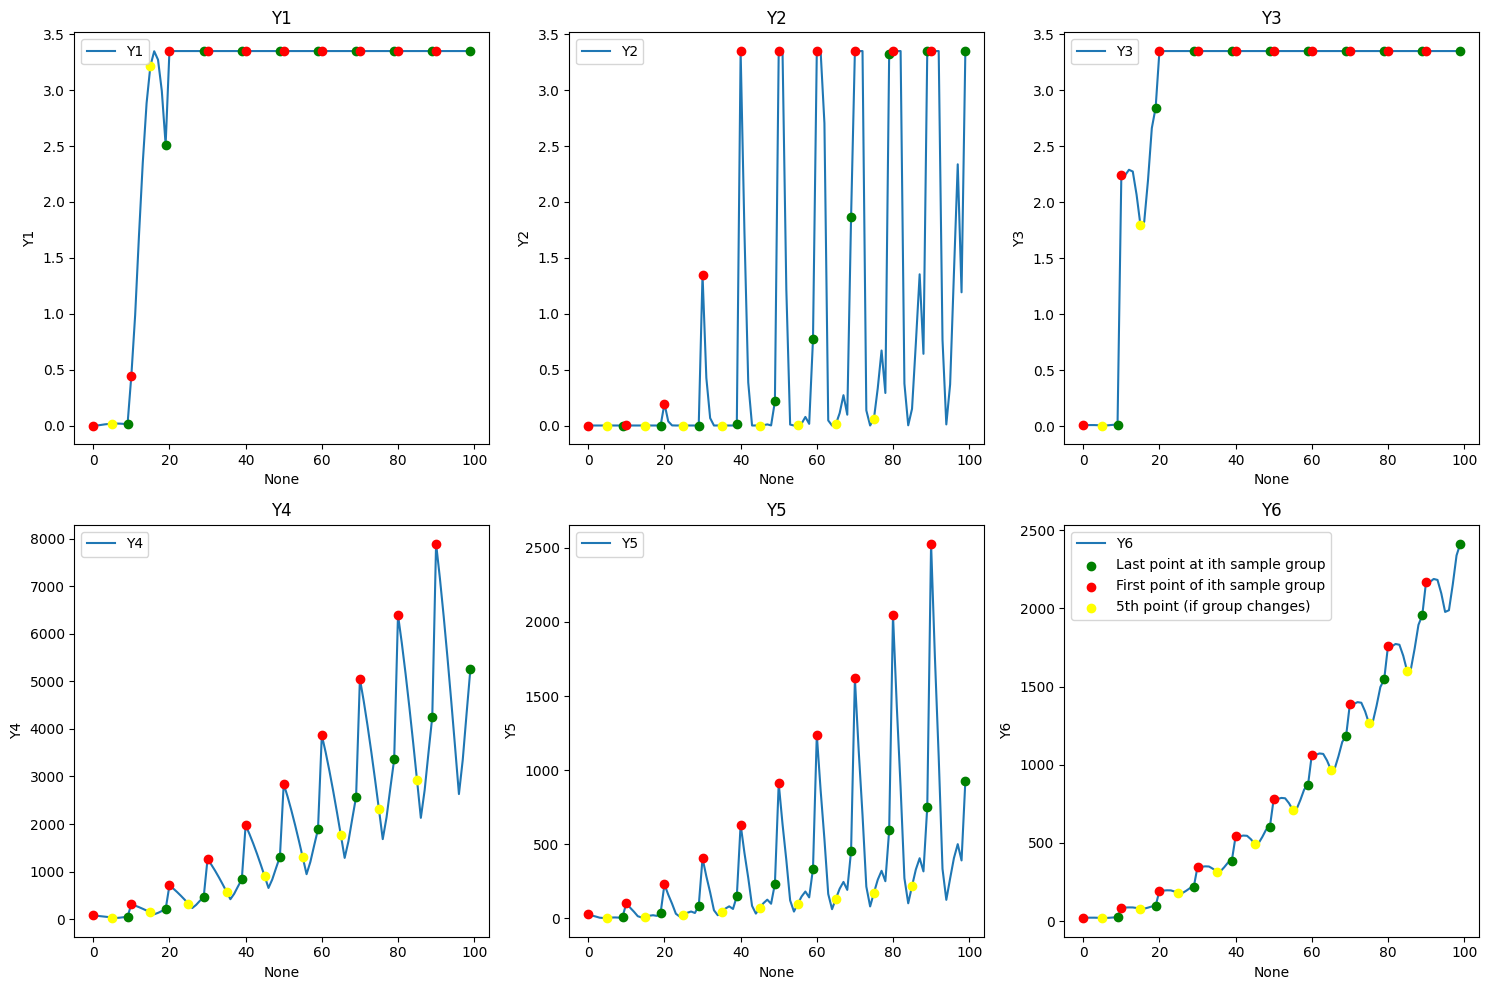

In [49]:
plot_cols(df)

# X7

In [70]:
df, input_df = load('X1_X7')
df

,Y1,Y2,Y3,Y4,Y5,Y6,Y7
0,0.006406,0.00,0.011692,61.360722,14.579067,23.065624,1
1,0.006406,0.00,0.011692,61.360722,14.579067,23.065624,1
2,0.006406,0.00,0.011692,61.360722,14.579067,23.065624,1
3,0.006406,0.00,0.011692,61.360722,14.579067,23.065624,1
4,0.006406,0.00,0.011692,61.360722,14.579067,23.065624,1
...,...,...,...,...,...,...,...
119995,3.350000,3.35,3.350000,6136.072152,1595.014866,2437.870704,2000
119996,3.350000,3.35,3.350000,6136.072152,1595.014866,2437.870704,2000
119997,3.350000,3.35,3.350000,6136.072152,1595.014866,2437.870704,2000
119998,3.350000,3.35,3.350000,6136.072152,1595.014866,2437.870704,2000


In [51]:
df = df.drop('Y7', axis = 1).drop_duplicates(keep='first').reset_index(drop=True)
df

,Y1,Y2,Y3,Y4,Y5,Y6
0,0.006406,0.00,0.011692,61.360722,14.579067,23.065624
1,0.006406,0.00,0.011318,61.360722,12.580667,22.851823
2,0.006406,0.00,0.010213,61.360722,10.465021,22.224691
3,0.006406,0.00,0.008950,61.360722,8.268327,21.518973
4,0.006406,0.00,0.009052,61.360722,6.028172,21.575324
...,...,...,...,...,...,...
95,3.350000,3.35,3.350000,6136.072152,767.362748,2257.692327
96,3.350000,3.35,3.350000,6136.072152,988.562831,2367.879773
97,3.350000,3.35,3.350000,6136.072152,1202.649536,2427.877947
98,3.350000,3.35,3.350000,6136.072152,1405.959779,2445.353647


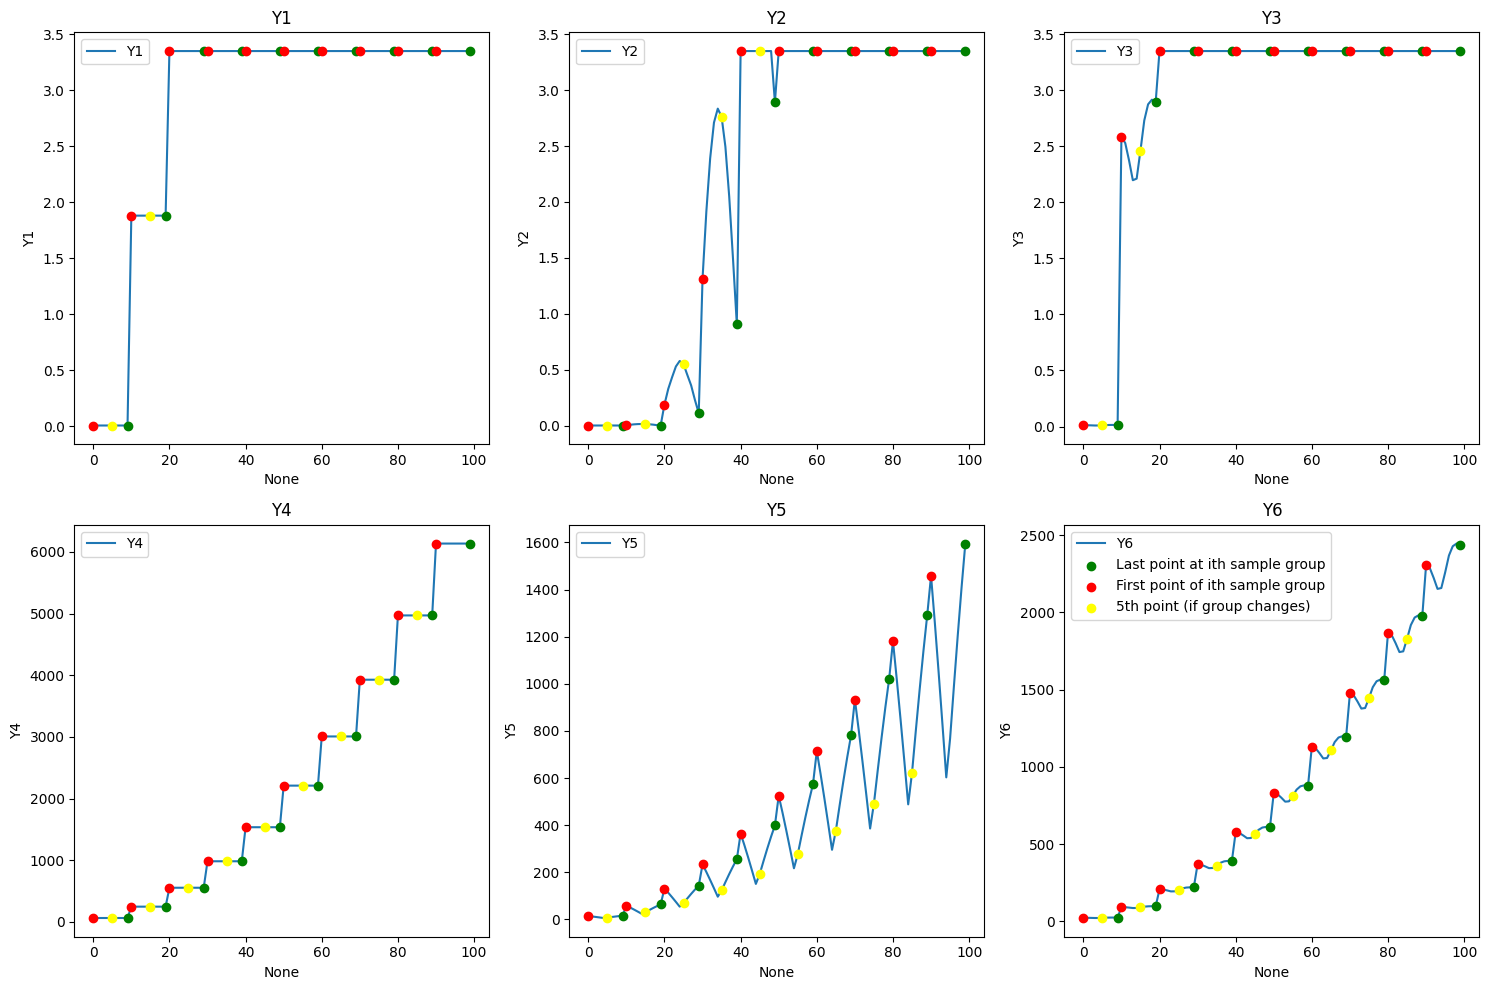

In [52]:
plot_cols(df)


# X8

In [71]:
df, input_df = load('X1_X8')
df

,Y1,Y2,Y3,Y4,Y5,Y6,Y7
0,0.006406,0.00,0.004118,61.360722,71.046656,18.923197,1
1,0.006406,0.00,0.004118,61.360722,71.046656,18.923197,1
2,0.006406,0.00,0.004118,61.360722,71.046656,18.923197,1
3,0.006406,0.00,0.004118,61.360722,71.046656,18.923197,1
4,0.006406,0.00,0.004118,61.360722,71.046656,18.923197,1
...,...,...,...,...,...,...,...
119995,3.350000,3.35,3.350000,6136.072152,3665.434666,2365.804934,2000
119996,3.350000,3.35,3.350000,6136.072152,3665.434666,2365.804934,2000
119997,3.350000,3.35,3.350000,6136.072152,3665.434666,2365.804934,2000
119998,3.350000,3.35,3.350000,6136.072152,3665.434666,2365.804934,2000


In [54]:
df = df.drop('Y7', axis = 1).drop_duplicates(keep='first').reset_index(drop=True)
df

,Y1,Y2,Y3,Y4,Y5,Y6
0,0.006406,0.00,0.004118,61.360722,71.046656,18.923197
1,0.006406,0.00,0.006075,61.360722,70.271785,19.954419
2,0.006406,0.00,0.007544,61.360722,69.276294,20.746510
3,0.006406,0.00,0.008679,61.360722,67.970372,21.368995
4,0.006406,0.00,0.009583,61.360722,66.217457,21.870862
...,...,...,...,...,...,...
95,3.350000,3.35,3.350000,6136.072152,6380.500226,2228.786151
96,3.350000,3.35,3.350000,6136.072152,6039.475722,2264.793829
97,3.350000,3.35,3.350000,6136.072152,5543.800287,2297.587303
98,3.350000,3.35,3.350000,6136.072152,4803.176972,2329.884687


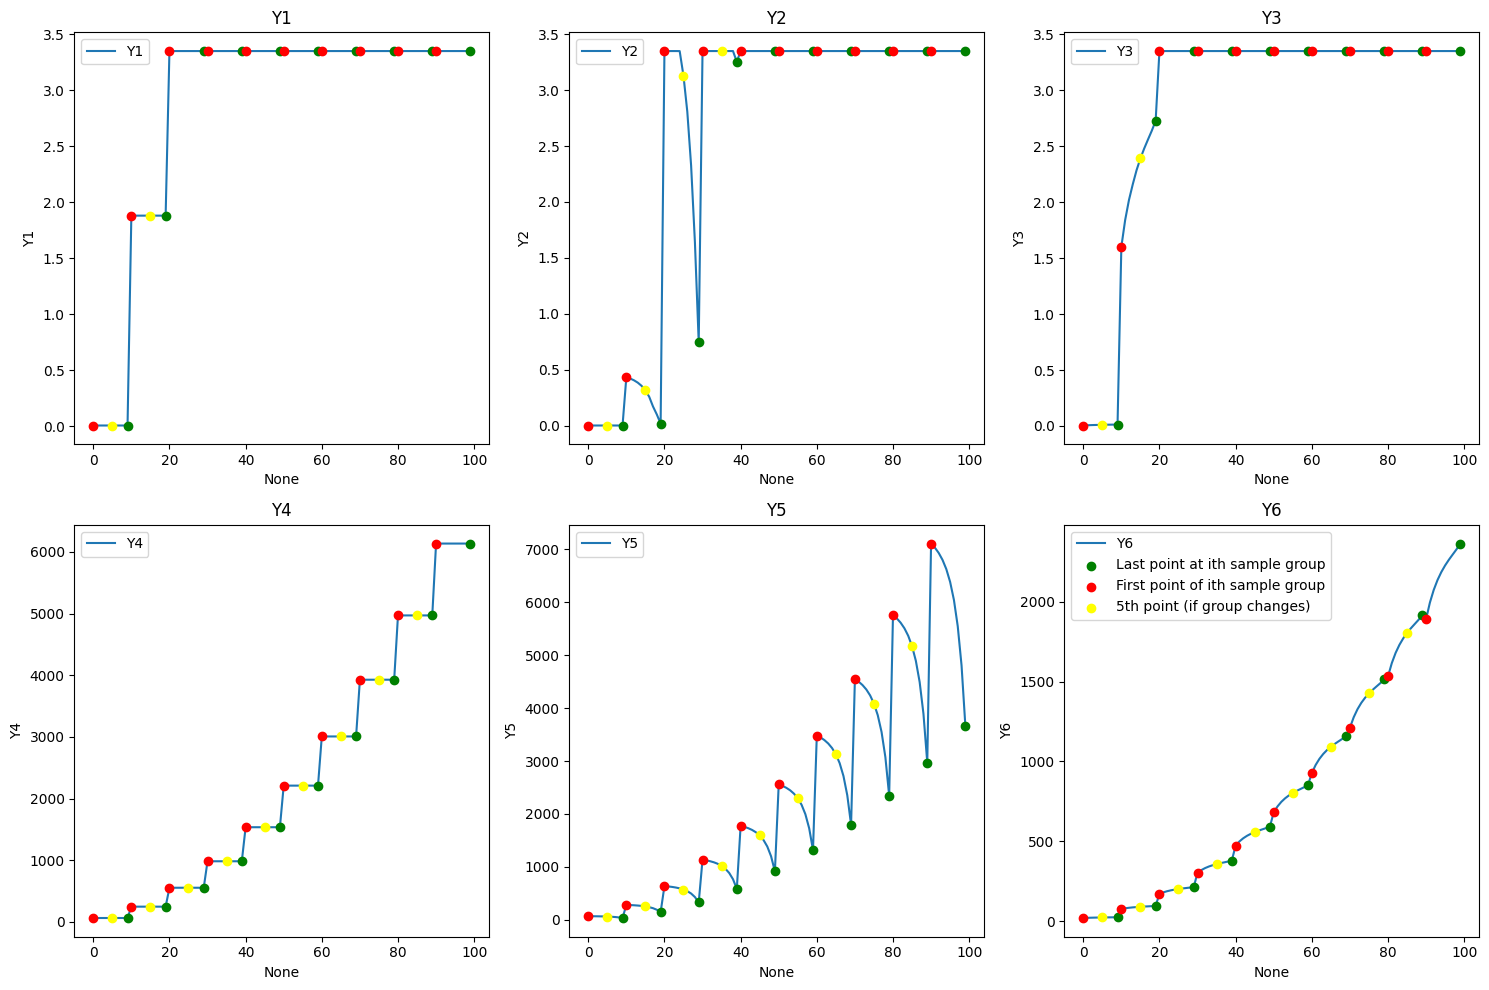

In [55]:
plot_cols(df)

# Fix all (without X2) while changing X1 and Xi (3 <= i <= 8)

In [72]:
df, input_df = load('X1_X3_0_1')
print(len(df))
df = df.drop('Y7', axis = 1).drop_duplicates(keep='first').reset_index(drop=True)
print(len(df))
df

120000
100


,Y1,Y2,Y3,Y4,Y5,Y6
0,0.009440,0.00,0.003828,56.101993,16.631586,19.724634
1,0.009625,0.00,0.004359,55.744228,17.590525,19.723531
2,0.009808,0.00,0.005051,55.385619,18.616995,19.803205
3,0.009990,0.00,0.005873,55.026177,19.705553,19.946848
4,0.010168,0.00,0.006795,54.665913,20.850218,20.136071
...,...,...,...,...,...,...
95,3.350000,3.35,3.350000,5430.483464,2204.453219,2035.183071
96,3.350000,3.35,3.350000,5394.295317,2328.163318,2057.540694
97,3.350000,3.35,3.350000,5358.027823,2455.434446,2100.821575
98,3.350000,3.35,3.350000,5321.681974,2585.527624,2187.593083


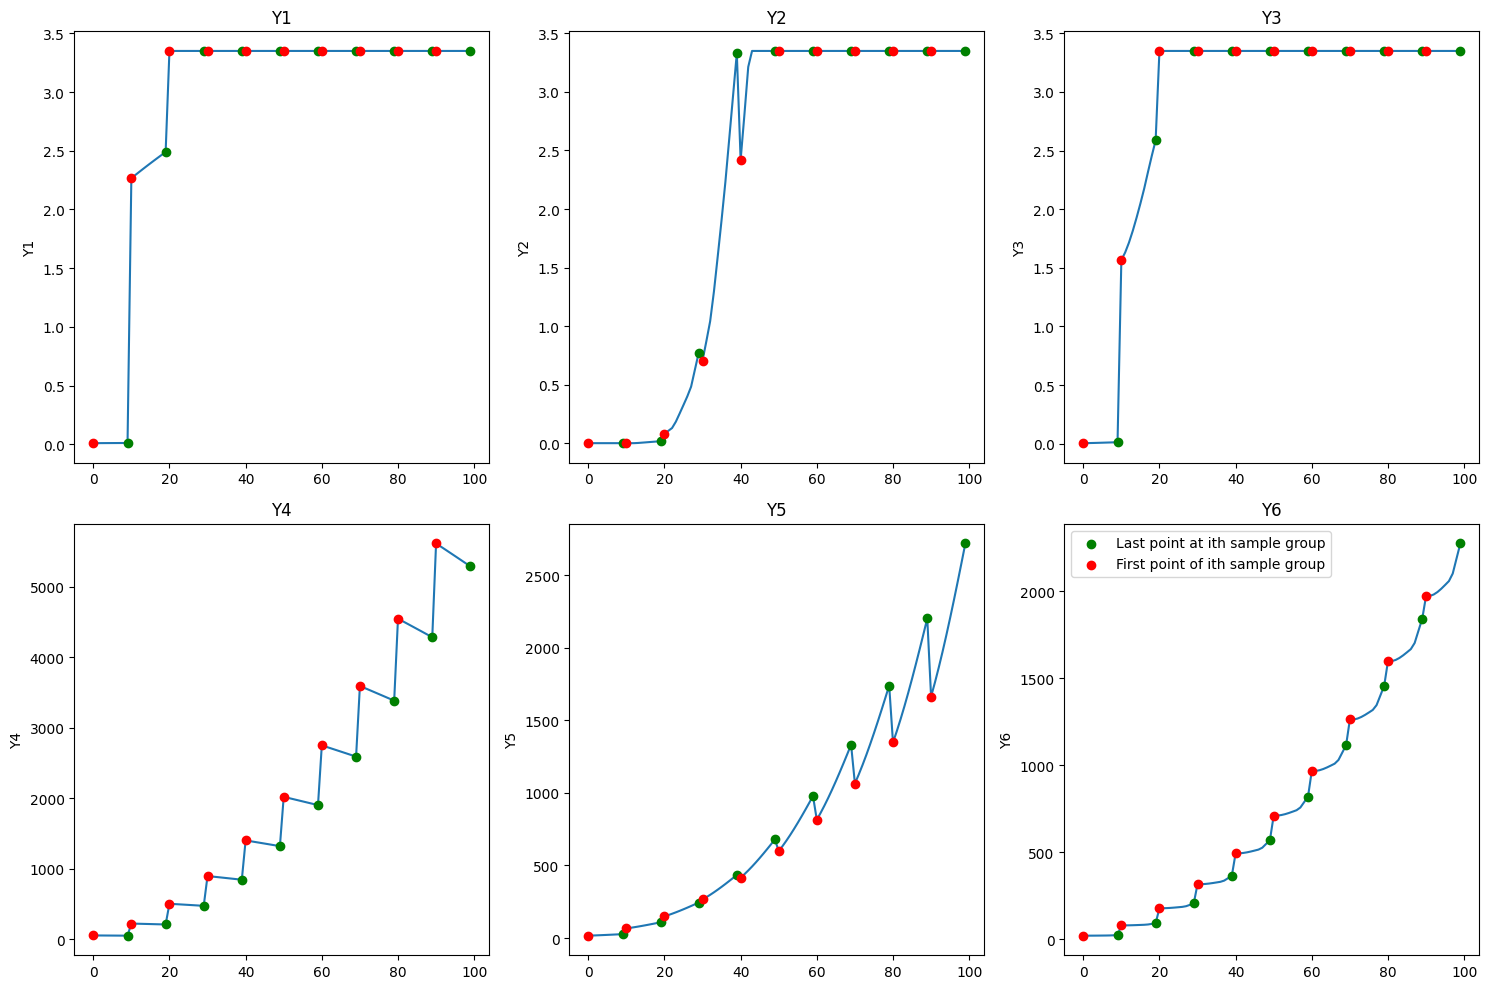

In [4]:
plot_cols(df)

In [73]:
df, input_df = load('X1_X4_0_1')
print(len(df))
df = df.drop('Y7', axis = 1).drop_duplicates(keep='first').reset_index(drop=True)
print(len(df))
df

120000
100


,Y1,Y2,Y3,Y4,Y5,Y6
0,0.01103,0.00,0.011883,52.852588,34.369779,22.826093
1,0.01103,0.00,0.011822,52.852588,33.727194,22.791673
2,0.01103,0.00,0.011768,52.852588,33.057454,22.761200
3,0.01103,0.00,0.011723,52.852588,32.357220,22.735435
4,0.01103,0.00,0.011687,52.852588,31.622354,22.715245
...,...,...,...,...,...,...
95,3.35000,3.35,3.350000,5285.258767,3084.764441,2270.161845
96,3.35000,3.35,3.350000,5285.258767,3002.638497,2269.567878
97,3.35000,3.35,3.350000,5285.258767,2914.972415,2269.870878
98,3.35000,3.35,3.350000,5285.258767,2820.560575,2271.217904


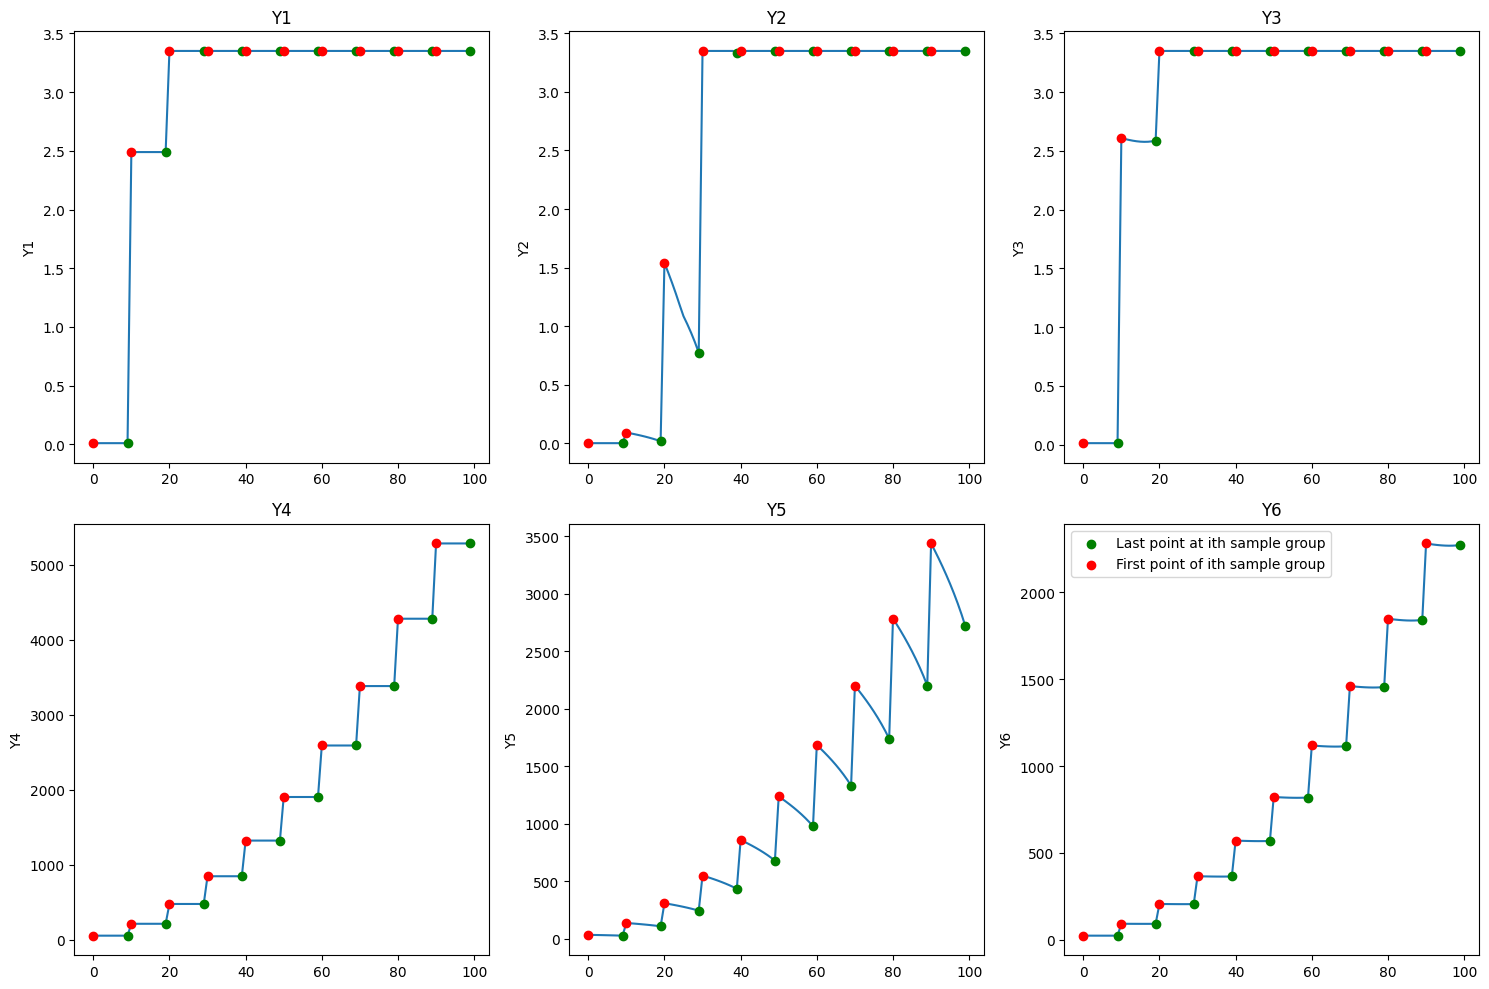

In [6]:
plot_cols(df)

In [74]:
df, input_df = load('X1_X5_0_1')
print(len(df))
df = df.drop('Y7', axis = 1).drop_duplicates(keep='first').reset_index(drop=True)
print(len(df))
df

120000
100


,Y1,Y2,Y3,Y4,Y5,Y6
0,0.01103,0.00,0.009926,52.852588,24.664017,21.730450
1,0.01103,0.00,0.010099,52.852588,24.916759,21.826181
2,0.01103,0.00,0.010278,52.852588,25.175669,21.925703
3,0.01103,0.00,0.010464,52.852588,25.440931,22.029141
4,0.01103,0.00,0.010657,52.852588,25.712734,22.136613
...,...,...,...,...,...,...
95,3.35000,3.35,3.350000,5285.258767,2599.127465,2224.822864
96,3.35000,3.35,3.350000,5285.258767,2627.675386,2236.408428
97,3.35000,3.35,3.350000,5285.258767,2656.937944,2248.426142
98,3.35000,3.35,3.350000,5285.258767,2686.936509,2260.882034


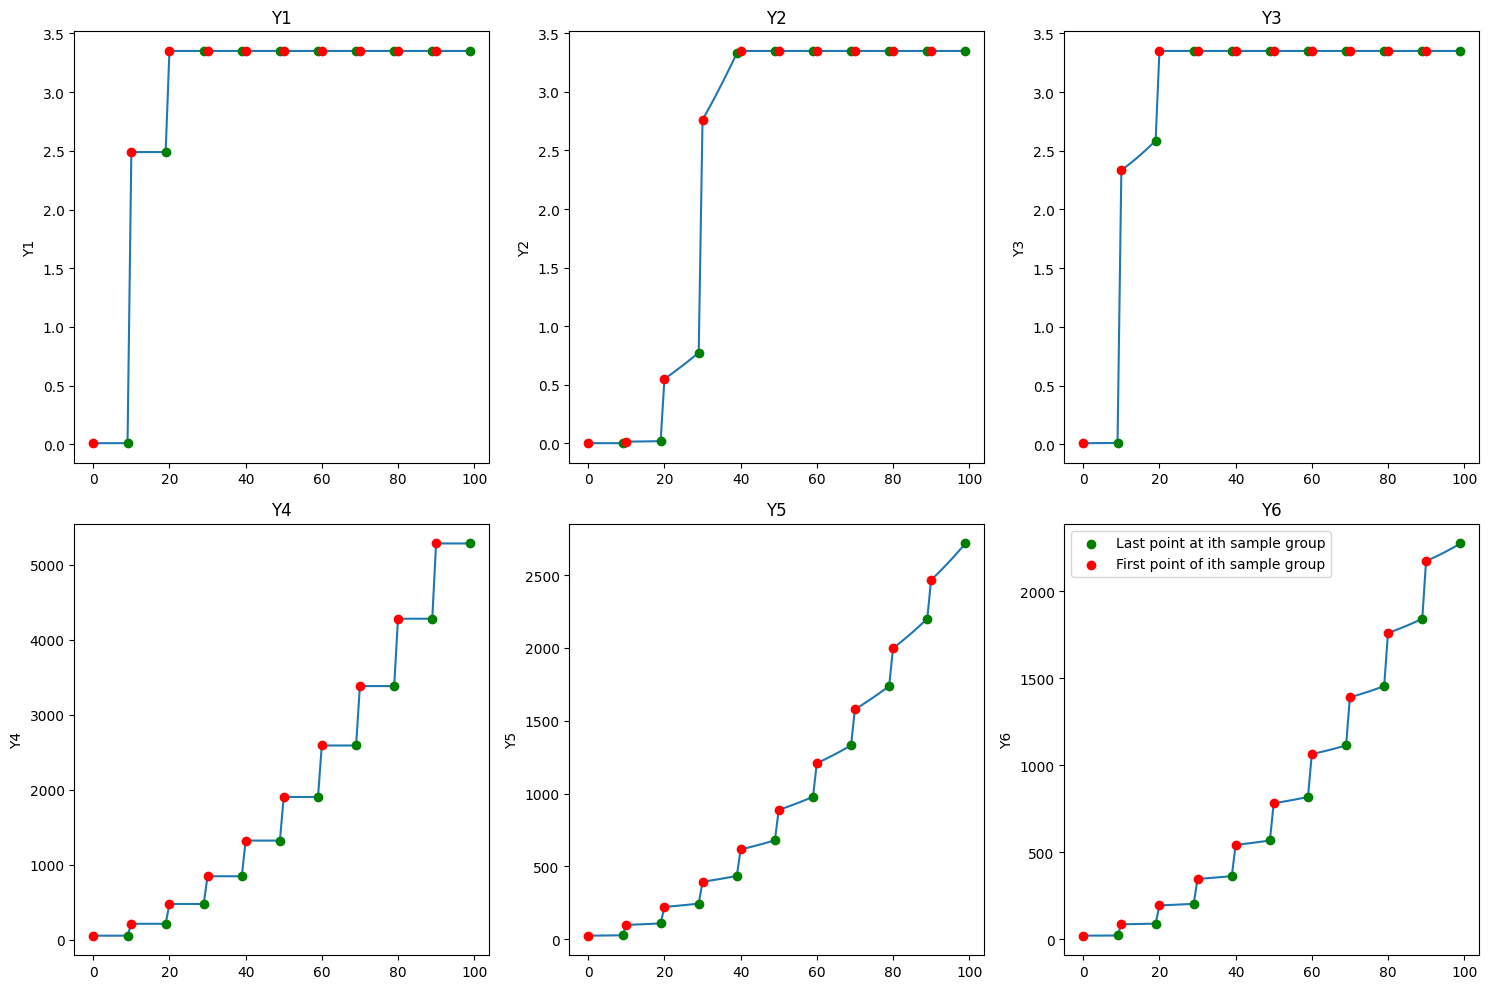

In [8]:
plot_cols(df)

In [75]:
df, input_df = load('X1_X6_0_1')
print(len(df))
df = df.drop('Y7', axis = 1).drop_duplicates(keep='first').reset_index(drop=True)
print(len(df))
df

120000
100


,Y1,Y2,Y3,Y4,Y5,Y6
0,0.000000,0.00,0.009346,78.676955,31.507369,21.410822
1,0.000000,0.00,0.009302,71.380630,27.698904,21.387137
2,0.005138,0.00,0.009431,63.290719,24.967174,21.457864
3,0.010228,0.00,0.008978,54.545643,20.810463,21.209322
4,0.013967,0.00,0.007516,45.295033,15.656997,20.418251
...,...,...,...,...,...,...
95,3.350000,3.35,3.350000,3569.717003,1230.030874,1945.234627
96,3.350000,3.35,3.350000,2591.627506,1204.907217,1937.021293
97,3.350000,3.35,3.350000,3388.029762,1462.157445,2053.736792
98,3.350000,3.35,3.350000,4352.492595,2023.260458,2195.199907


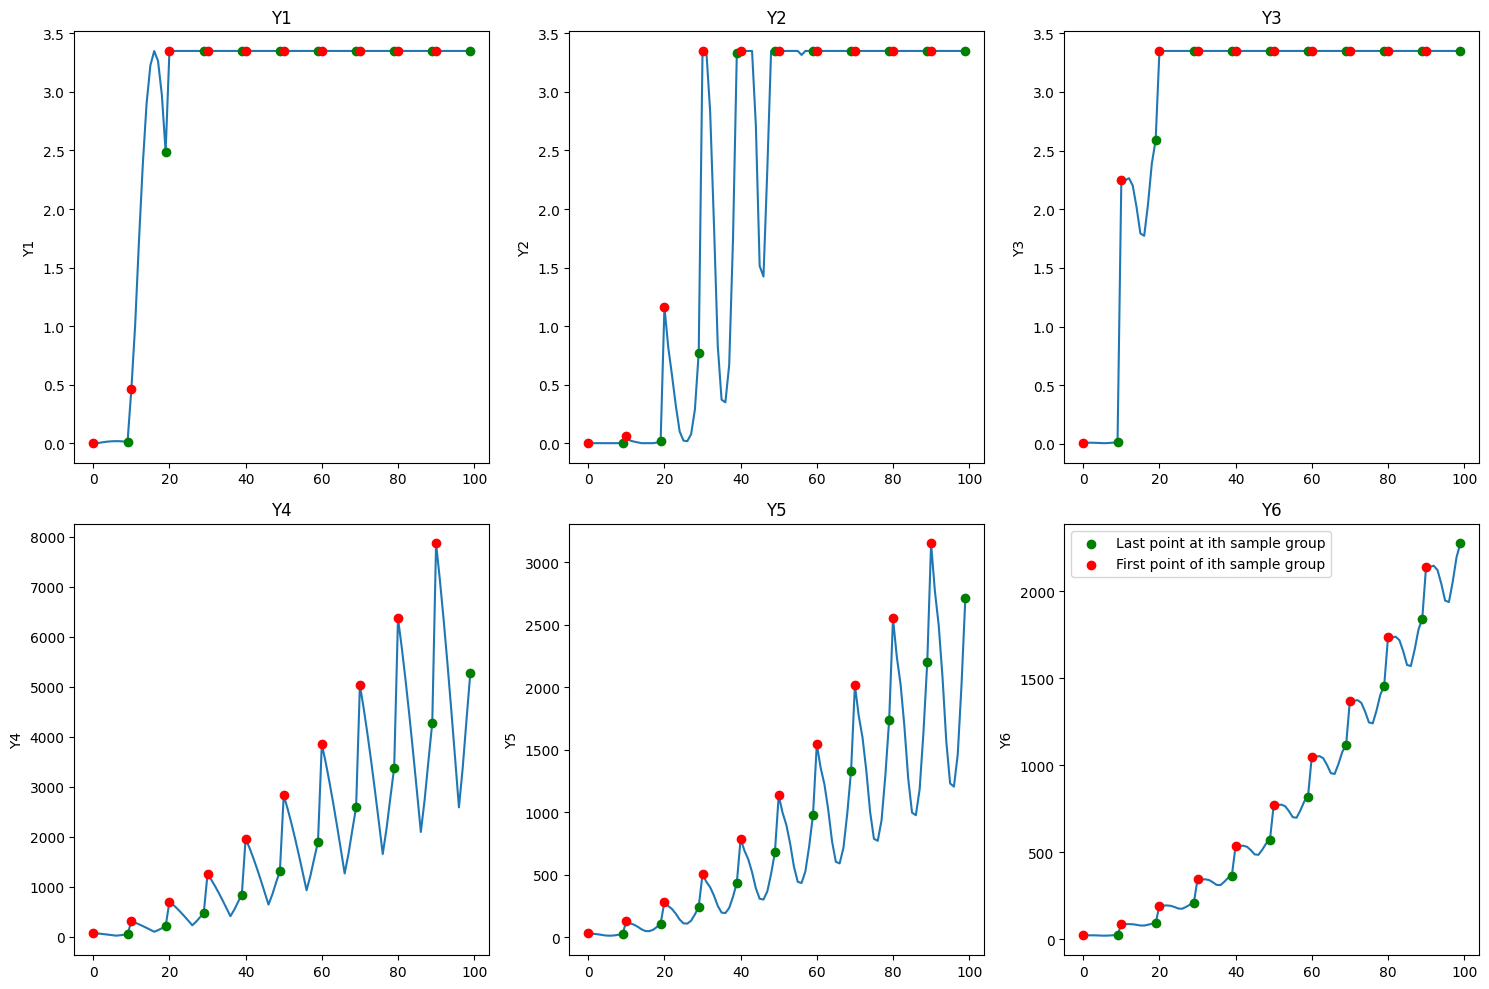

In [10]:
plot_cols(df)


In [76]:
df, input_df = load('X1_X7_0_1')
print(len(df))
df = df.drop('Y7', axis = 1).drop_duplicates(keep='first').reset_index(drop=True)
print(len(df))
df

120000
100


,Y1,Y2,Y3,Y4,Y5,Y6
0,0.01103,0.00,0.009697,52.852588,24.597840,21.604243
1,0.01103,0.00,0.009193,52.852588,21.199080,21.327293
2,0.01103,0.00,0.007728,52.852588,17.603845,20.532335
3,0.01103,0.00,0.005937,52.852588,13.873650,19.580860
4,0.01103,0.00,0.005664,52.852588,10.072320,19.437746
...,...,...,...,...,...,...
95,3.35000,3.35,3.350000,5285.258767,1316.752517,2045.030323
96,3.35000,3.35,3.350000,5285.258767,1691.589502,2177.190207
97,3.35000,3.35,3.350000,5285.258767,2054.107629,2258.159387
98,3.35000,3.35,3.350000,5285.258767,2398.104112,2283.545664


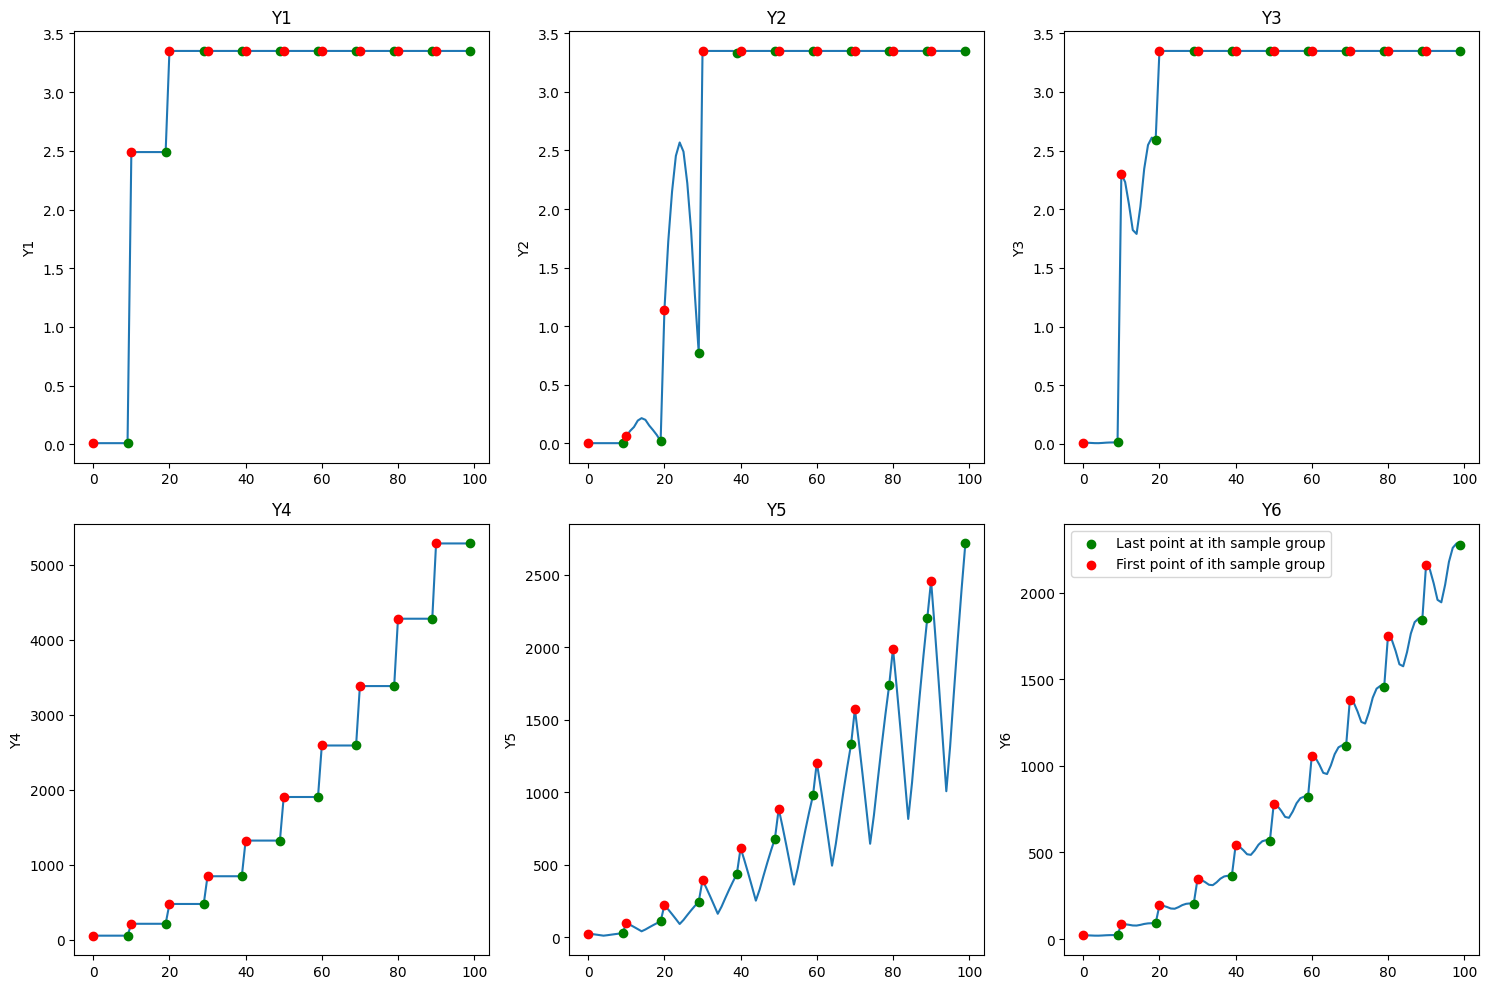

In [12]:
plot_cols(df)

In [77]:
df, input_df = load('X1_X8_0_1')
print(len(df))
df = df.drop('Y7', axis = 1).drop_duplicates(keep='first').reset_index(drop=True)
print(len(df))
df

120000
100


,Y1,Y2,Y3,Y4,Y5,Y6
0,0.01103,0.00,0.003190,52.852588,61.480187,18.165575
1,0.01103,0.00,0.005209,52.852588,60.535421,19.200664
2,0.01103,0.00,0.006682,52.852588,59.352616,19.974146
3,0.01103,0.00,0.007797,52.852588,57.843892,20.569347
4,0.01103,0.00,0.008671,52.852588,55.879891,21.042237
...,...,...,...,...,...,...
95,3.35000,3.35,3.350000,5285.258767,5326.639618,2143.204719
96,3.35000,3.35,3.350000,5285.258767,4970.626668,2176.841714
97,3.35000,3.35,3.350000,5285.258767,4473.736594,2207.696258
98,3.35000,3.35,3.350000,5285.258767,3762.979245,2238.552012


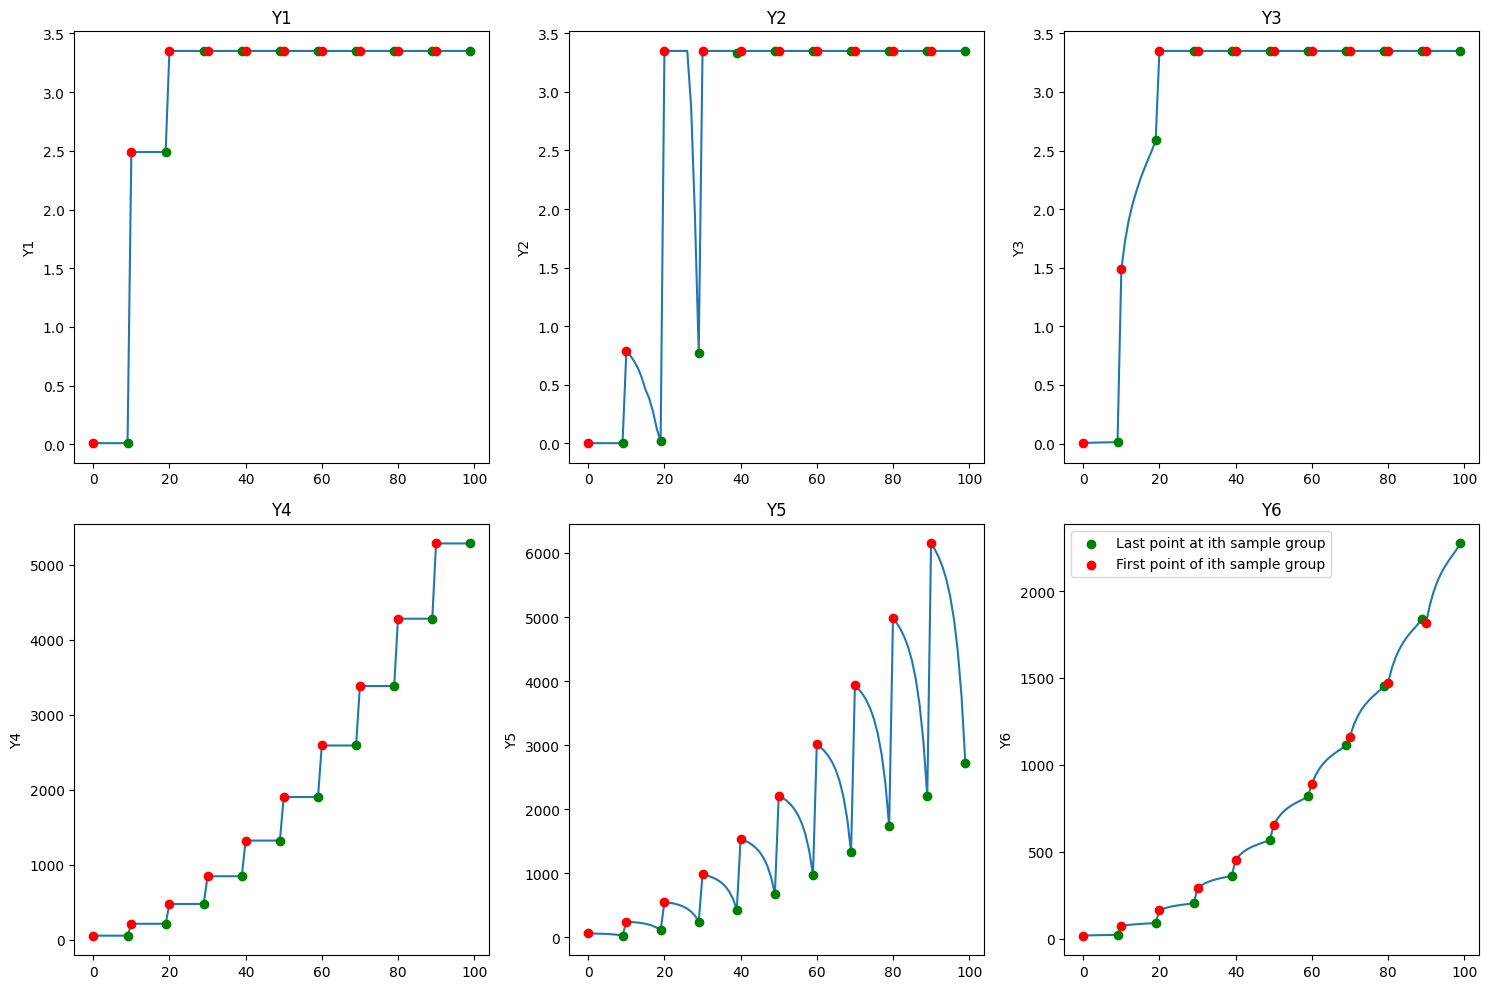

In [14]:
plot_cols(df)

# TODO:

1. Determine the distribution of X2. - generate many samples with different seeds and try to model the noise i.e. X2 by comparing it to different known distributions.
